A1 & A2 - Single Attribute Regression
Train (MSE, RMSE, MAPE, R2): (1.3328856479495677, 1.154506668646642, 54.38358310616024, 0.04878713853721006)
Test  (MSE, RMSE, MAPE, R2): (1.3262710012225587, 1.1516383986401977, 51.90485723664003, 0.058721224859765386)

A3 - All Attribute Regression
Train (MSE, RMSE, MAPE, R2): (1.3328754313676885, 1.154502243985558, 54.386543117768746, 0.048794429593347344)
Test  (MSE, RMSE, MAPE, R2): (1.3265054028873446, 1.1517401629218913, 51.91445588843908, 0.058554865713167814)

A4 & A5 - KMeans Clustering (k=2)
Cluster Centers:
 [[ 621.56115108  128.89496403   17.65467626]
 [2727.2780112   238.08263305   14.70938375]]
Silhouette Score: 0.6672122811517537
Calinski-Harabasz Score: 6658.227429222243
Davies-Bouldin Index: 0.425926051270044

A6 - Scores for different K
Silhouette Scores: [0.6672122811517537, 0.6468450814978693, 0.6343975311805131, 0.6492827500613128, 0.6344083097941551, 0.5928949273954218, 0.589487750080686, 0.5864345703856119]
CH Scores: [6658.

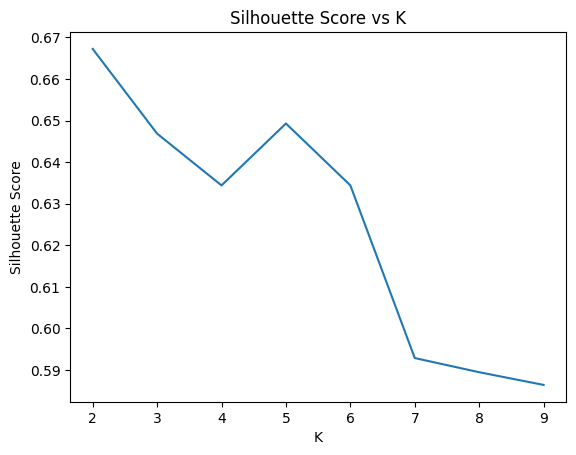

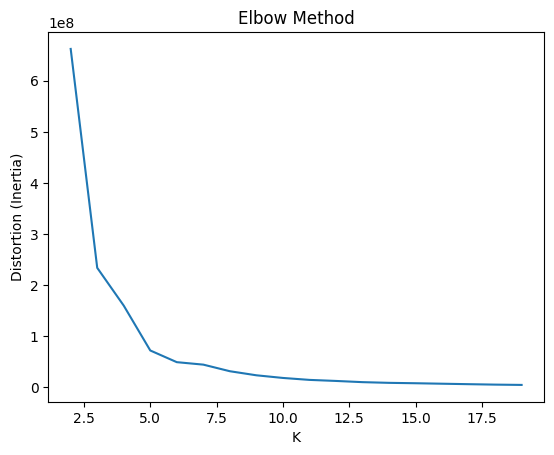

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

def calculate_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    return mse, rmse, mape, r2

# A1 & A2 - Linear Regression (Single Attribute

def regression_single_attribute(X_train, X_test, y_train, y_test):

    X_train_single = X_train[:, [0]]
    X_test_single = X_test[:, [0]]

    model = LinearRegression()
    model.fit(X_train_single, y_train)

    y_train_pred = model.predict(X_train_single)
    y_test_pred = model.predict(X_test_single)

    train_metrics = calculate_metrics(y_train, y_train_pred)
    test_metrics = calculate_metrics(y_test, y_test_pred)

    return train_metrics, test_metrics

# A3 - Linear Regression (All Attributes)

def regression_all_attributes(X_train, X_test, y_train, y_test):

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_metrics = calculate_metrics(y_train, y_train_pred)
    test_metrics = calculate_metrics(y_test, y_test_pred)

    return train_metrics, test_metrics

# A4 & A5 - KMeans Clustering

def kmeans_clustering(X_train, k):

    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    kmeans.fit(X_train)

    labels = kmeans.labels_

    silhouette = silhouette_score(X_train, labels)
    ch_score = calinski_harabasz_score(X_train, labels)
    db_index = davies_bouldin_score(X_train, labels)

    return kmeans.cluster_centers_, silhouette, ch_score, db_index

# A6 - Evaluate Different K Values

def evaluate_multiple_k(X_train, k_range):

    silhouette_scores = []
    ch_scores = []
    db_scores = []

    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
        kmeans.fit(X_train)
        labels = kmeans.labels_

        silhouette_scores.append(silhouette_score(X_train, labels))
        ch_scores.append(calinski_harabasz_score(X_train, labels))
        db_scores.append(davies_bouldin_score(X_train, labels))

    return silhouette_scores, ch_scores, db_scores

# A7 - Elbow Method

def elbow_plot(X_train, k_range):

    distortions = []

    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
        kmeans.fit(X_train)
        distortions.append(kmeans.inertia_)

    return distortions

def main():

    dataset = pd.read_excel("Conf_Text_Labels.xlsx")


    dataset = dataset.dropna()

    y = dataset["Conf Label"].values
    X = dataset.select_dtypes(include=np.number).drop(columns=["Conf Label"]).values

    # Train-Test Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

#1,2
    train_single, test_single = regression_single_attribute(
        X_train, X_test, y_train, y_test
    )

    print("A1 & A2 - Single Attribute Regression")
    print("Train (MSE, RMSE, MAPE, R2):", train_single)
    print("Test  (MSE, RMSE, MAPE, R2):", test_single)

#4,3
    train_multi, test_multi = regression_all_attributes(
        X_train, X_test, y_train, y_test
    )

    print("\nA3 - All Attribute Regression")
    print("Train (MSE, RMSE, MAPE, R2):", train_multi)
    print("Test  (MSE, RMSE, MAPE, R2):", test_multi)

#5
    centers, silhouette, ch_score, db_index = kmeans_clustering(X_train, 2)

    print("\nA4 & A5 - KMeans Clustering (k=2)")
    print("Cluster Centers:\n", centers)
    print("Silhouette Score:", silhouette)
    print("Calinski-Harabasz Score:", ch_score)
    print("Davies-Bouldin Index:", db_index)

#6
    k_range = range(2, 10)
    silhouette_scores, ch_scores, db_scores = evaluate_multiple_k(X_train, k_range)

    print("\nA6 - Scores for different K")
    print("Silhouette Scores:", silhouette_scores)
    print("CH Scores:", ch_scores)
    print("DB Scores:", db_scores)

    # Plot Silhouette vs K
    plt.figure()
    plt.plot(list(k_range), silhouette_scores)
    plt.title("Silhouette Score vs K")
    plt.xlabel("K")
    plt.ylabel("Silhouette Score")
    plt.show()
#a7
    distortions = elbow_plot(X_train, range(2, 20))

    plt.figure()
    plt.plot(range(2, 20), distortions)
    plt.title("Elbow Method")
    plt.xlabel("K")
    plt.ylabel("Distortion (Inertia)")
    plt.show()

if __name__ == "__main__":
    main()